# Customer Analytics and Segmentation

**Synthetic-data case study.** This notebook turns normalized e-commerce tables into a customer-level analytical table with SQL, then uses behavioral features to identify actionable customer groups.

## 1. Business Problem

The goal is to understand who our customers are, how they behave, which customers are most valuable, and which groups need retention or reactivation. All records and results are synthetic and exist only for demonstration.

## 2. Dataset Overview

The generator creates customers, products, orders, and order items across 24 months. The seed is fixed for reproducibility.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "sample"
ASSET_DIR = PROJECT_ROOT / "assets"
ASSET_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

plt.style.use("default")
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.max_columns", 12)

customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
products = pd.read_csv(DATA_DIR / "products.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv")

overview = pd.DataFrame({
    "table": ["customers", "products", "orders", "order_items"],
    "rows": [len(customers), len(products), len(orders), len(order_items)],
    "columns": [customers.shape[1], products.shape[1], orders.shape[1], order_items.shape[1]],
})
overview

,table,rows,columns
0,customers,4000,4
1,products,180,4
2,orders,22373,4
3,order_items,52993,4


In [2]:
assert customers["customer_id"].is_unique
assert products["product_id"].is_unique
assert orders["order_id"].is_unique
assert orders["customer_id"].isin(customers["customer_id"]).all()
assert order_items["order_id"].isin(orders["order_id"]).all()
assert order_items["product_id"].isin(products["product_id"]).all()
print(f"Coverage: {orders['order_date'].min().date()} to {orders['order_date'].max().date()}")
print("Key integrity checks passed.")

Coverage: 2024-01-03 to 2025-12-31
Key integrity checks passed.


## 3. SQL Feature Extraction

The raw tables are loaded into an in-memory SQLite database. The repository SQL uses CTEs and a window function to calculate one row per purchasing customer—including RFM features, purchase cadence, category breadth, and favorite category.

In [3]:
connection = sqlite3.connect(":memory:")
customers.assign(signup_date=customers["signup_date"].dt.strftime("%Y-%m-%d")).to_sql("customers", connection, index=False)
products.to_sql("products", connection, index=False)
orders.assign(order_date=orders["order_date"].dt.strftime("%Y-%m-%d")).to_sql("orders", connection, index=False)
order_items.to_sql("order_items", connection, index=False)

feature_sql = (PROJECT_ROOT / "sql" / "customer_features.sql").read_text(encoding="utf-8")
customer_features = pd.read_sql_query(feature_sql, connection, parse_dates=["first_purchase_date", "last_purchase_date"])
connection.close()
customer_features.head().round(2)

,customer_id,recency_days,frequency,monetary_value,average_order_value,days_since_first_purchase,average_purchase_interval,unique_categories,favorite_category,last_purchase_date,first_purchase_date
0,C0001,28,5,315.43,63.09,264,59.0,3,Beauty,2025-12-03,2025-04-11
1,C0002,1,12,1330.16,110.85,601,54.5,6,Home,2025-12-30,2024-05-09
2,C0003,12,9,727.93,80.88,300,36.0,5,Grocery,2025-12-19,2025-03-06
3,C0004,513,3,301.06,100.35,637,62.0,3,Books,2024-08-05,2024-04-03
4,C0005,461,1,133.58,133.58,461,NaN,4,Grocery,2024-09-26,2024-09-26


## 4. E-commerce KPIs

These KPIs describe the generated demonstration period; they are not real company results.

In [4]:
orders_per_customer = orders.groupby("customer_id")["order_id"].nunique()
kpis = pd.DataFrame({
    "KPI": ["Total revenue", "Total orders", "Purchasing customers", "Average order value", "Repeat purchase rate", "Orders per customer"],
    "Value": [
        f"${orders['total_amount'].sum():,.0f}",
        f"{orders['order_id'].nunique():,}",
        f"{orders['customer_id'].nunique():,}",
        f"${orders['total_amount'].mean():,.2f}",
        f"{orders_per_customer.gt(1).mean():.1%}",
        f"{orders_per_customer.mean():.2f}",
    ],
})
kpis

,KPI,Value
0,Total revenue,"$2,502,970"
1,Total orders,"22,373"
2,Purchasing customers,"3,771"
3,Average order value,$111.87
4,Repeat purchase rate,88.9%
5,Orders per customer,5.93


## 5. Customer Feature Engineering

K-Means is sensitive to scale and skew. Missing intervals (single-order customers) are median-imputed; skewed non-negative features are transformed with `log1p`; then every feature is standardized. Dates themselves are not passed to the model.

In [5]:
segmentation_features = [
    "recency_days", "frequency", "monetary_value", "average_order_value",
    "days_since_first_purchase", "average_purchase_interval", "unique_categories",
]
model_frame = customer_features[segmentation_features].copy()
model_frame["average_purchase_interval"] = model_frame["average_purchase_interval"].fillna(
    model_frame["average_purchase_interval"].median()
)
skewed_features = ["recency_days", "frequency", "monetary_value", "average_order_value", "average_purchase_interval"]
model_frame[skewed_features] = np.log1p(model_frame[skewed_features])
scaled_features = StandardScaler().fit_transform(model_frame)

## 6. Customer Segmentation

We compare a small range of cluster counts using inertia and silhouette score. The final choice also considers whether the profiles translate into distinct business actions; silhouette is evidence, not an automatic decision rule.

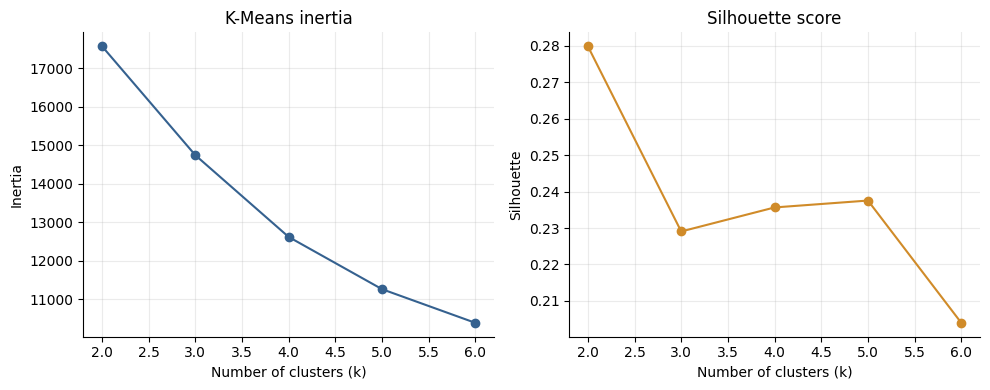

,k,inertia,silhouette
0,2,17574.940,0.280
1,3,14742.890,0.229
2,4,12617.802,0.236
3,5,11260.864,0.238
4,6,10385.654,0.204


In [6]:
cluster_diagnostics = []
for k in range(2, 7):
    candidate = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = candidate.fit_predict(scaled_features)
    cluster_diagnostics.append({
        "k": k,
        "inertia": candidate.inertia_,
        "silhouette": silhouette_score(scaled_features, labels),
    })
diagnostics = pd.DataFrame(cluster_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(diagnostics["k"], diagnostics["inertia"], marker="o", color="#35618f")
axes[0].set(title="K-Means inertia", xlabel="Number of clusters (k)", ylabel="Inertia")
axes[1].plot(diagnostics["k"], diagnostics["silhouette"], marker="o", color="#d08b29")
axes[1].set(title="Silhouette score", xlabel="Number of clusters (k)", ylabel="Silhouette")
for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(ASSET_DIR / "cluster_selection.png", dpi=160, bbox_inches="tight")
plt.show()
diagnostics.round(3)

In [7]:
SELECTED_K = 5
segment_model = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=20)
customer_features["cluster"] = segment_model.fit_predict(scaled_features)

raw_profiles = customer_features.groupby("cluster").agg(
    customer_count=("customer_id", "size"),
    average_recency=("recency_days", "mean"),
    average_frequency=("frequency", "mean"),
    average_monetary_value=("monetary_value", "mean"),
    average_aov=("average_order_value", "mean"),
    average_tenure=("days_since_first_purchase", "mean"),
)
normalized_profiles = (raw_profiles - raw_profiles.mean()) / raw_profiles.std(ddof=0)

unassigned = set(raw_profiles.index)
high_value = (normalized_profiles["average_frequency"] + normalized_profiles["average_monetary_value"] - normalized_profiles["average_recency"]).idxmax()
unassigned.remove(high_value)
at_risk = normalized_profiles.loc[list(unassigned), "average_recency"].idxmax()
unassigned.remove(at_risk)
new_promising = normalized_profiles.loc[list(unassigned), "average_tenure"].idxmin()
unassigned.remove(new_promising)
low_frequency = (normalized_profiles.loc[list(unassigned), "average_frequency"] + normalized_profiles.loc[list(unassigned), "average_monetary_value"]).idxmin()
unassigned.remove(low_frequency)
loyal = unassigned.pop()

segment_names = {
    high_value: "High Value Loyal",
    loyal: "Loyal Customers",
    new_promising: "New / Promising",
    at_risk: "At Risk",
    low_frequency: "Low Frequency",
}
customer_features["segment"] = customer_features["cluster"].map(segment_names)

## 7. Segment Interpretation

Five clusters preserve useful lifecycle distinctions without creating an unwieldy targeting scheme.

In [8]:
segment_summary = (
    customer_features.groupby("segment")
    .agg(
        customer_count=("customer_id", "size"),
        average_recency=("recency_days", "mean"),
        average_frequency=("frequency", "mean"),
        average_monetary_value=("monetary_value", "mean"),
        average_aov=("average_order_value", "mean"),
    )
    .sort_values("average_monetary_value", ascending=False)
)
segment_summary.round({"average_recency": 1, "average_frequency": 1, "average_monetary_value": 0, "average_aov": 0})

,customer_count,average_recency,average_frequency,average_monetary_value,average_aov
segment,,,,,
High Value Loyal,995,49.8,12.3,1667.0,132.0
At Risk,654,401.7,3.6,387.0,118.0
New / Promising,815,46.8,3.6,354.0,101.0
Loyal Customers,777,115.1,5.0,346.0,71.0
Low Frequency,530,230.8,1.7,63.0,39.0


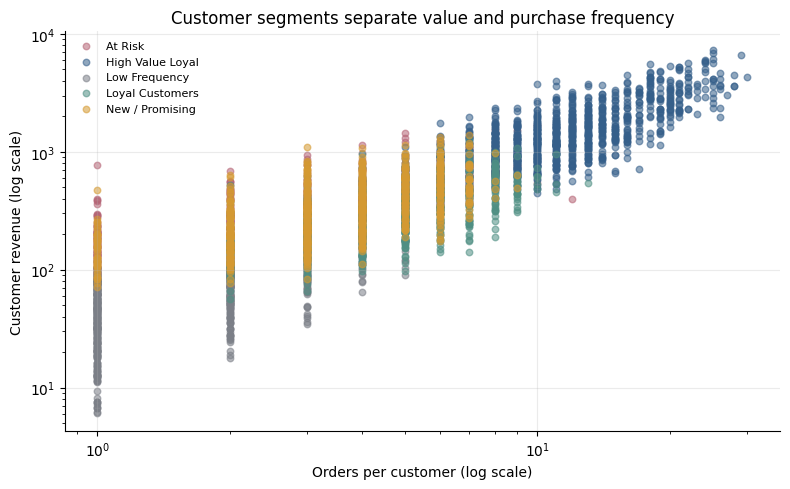

In [9]:
palette = {
    "High Value Loyal": "#355f8a", "Loyal Customers": "#4f8f83",
    "New / Promising": "#d59a32", "At Risk": "#b56576", "Low Frequency": "#7b7f87",
}
fig, axis = plt.subplots(figsize=(8, 5))
for segment, group in customer_features.groupby("segment"):
    axis.scatter(group["frequency"], group["monetary_value"], s=22, alpha=0.55, label=segment, color=palette[segment])
axis.set(xlabel="Orders per customer (log scale)", ylabel="Customer revenue (log scale)", title="Customer segments separate value and purchase frequency")
axis.set_xscale("log")
axis.set_yscale("log")
axis.legend(frameon=False, fontsize=8)
axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(ASSET_DIR / "customer_segments.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Business Actions

Actions are hypotheses to test—not claims of causal uplift.

In [10]:
business_actions = pd.DataFrame({
    "segment": ["High Value Loyal", "Loyal Customers", "New / Promising", "At Risk", "Low Frequency"],
    "example_action": [
        "VIP benefits and personalized cross-sell",
        "Loyalty rewards and replenishment reminders",
        "Second-order onboarding offer",
        "Time-bounded reactivation campaign",
        "Low-cost nurture and category discovery",
    ],
})
business_actions

,segment,example_action
0,High Value Loyal,VIP benefits and personalized cross-sell
1,Loyal Customers,Loyalty rewards and replenishment reminders
2,New / Promising,Second-order onboarding offer
3,At Risk,Time-bounded reactivation campaign
4,Low Frequency,Low-cost nurture and category discovery


## 9. Key Takeaways

- SQL provides a transparent bridge from transaction tables to reusable customer features.
- Five clusters balance quantitative separation with distinct, explainable marketing actions.
- The synthetic results show how segmentation supports prioritization; experiments are still needed to estimate incremental impact.